In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
career_df = pd.read_csv("../dataset/career_dataset_large_cleaned.csv")

In [22]:
career_df.head()

,Specialization,Certifications,CGPA/Percentage,Skills_ID_Categorized,Recommended_Career,Education_Level_ID_Categorized,Certifications_ID_Categorized
0,Finance,Tally ERP,67,"Konseling, MS Office, Machine Learning",Business Analyst,Sarjana,Keuangan & ERP
1,Science,AWS Certified,67,"Keuangan & Akuntansi, MS Office",Software Engineer,SMA/Sederajat,Cloud bersertifikat (AWS)
2,Business,Mental Health Basics,90,"Analisis Data & IT, Keuangan & Akuntansi, SQL",Financial Analyst,Magister,Kesehatan Mental
3,Computer Science,No Certification,75,Komunikasi,Staf Administrasi,Sarjana,Tanpa Sertifikat
4,Business,Tally ERP,83,Analisis Data & IT,Asisten Penjualan,SMA/Sederajat,Keuangan & ERP


In [23]:
career_df.shape

(4999, 7)

In [24]:
career_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Specialization                  4999 non-null   str  
 1   Certifications                  4999 non-null   str  
 2   CGPA/Percentage                 4999 non-null   int64
 3   Skills_ID_Categorized           4999 non-null   str  
 4   Recommended_Career              4999 non-null   str  
 5   Education_Level_ID_Categorized  4999 non-null   str  
 6   Certifications_ID_Categorized   4999 non-null   str  
dtypes: int64(1), str(6)
memory usage: 725.1 KB


In [25]:
career_df.describe(include="all")

,Specialization,Certifications,CGPA/Percentage,Skills_ID_Categorized,Recommended_Career,Education_Level_ID_Categorized,Certifications_ID_Categorized
count,4999,4999,4999.000000,4999,4999,4999,4999
unique,8,8,NaN,129,12,4,8
top,Engineering,Mental Health Basics,NaN,Keuangan & Akuntansi,Staf Administrasi,SMA/Sederajat,Kesehatan Mental
freq,668,673,NaN,410,432,1987,673
mean,NaN,NaN,77.478096,NaN,NaN,NaN,NaN
std,NaN,NaN,10.396630,NaN,NaN,NaN,NaN
min,NaN,NaN,60.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,68.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,77.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,87.000000,NaN,NaN,NaN,NaN


In [26]:
career_df.isnull().sum()

Specialization                    0
Certifications                    0
CGPA/Percentage                   0
Skills_ID_Categorized             0
Recommended_Career                0
Education_Level_ID_Categorized    0
Certifications_ID_Categorized     0
dtype: int64

In [27]:
career_df.duplicated().sum()

np.int64(1)

In [28]:
career_df = career_df.drop_duplicates().copy()

In [29]:
print("Shape setelah cleaning:", career_df.shape)

Shape setelah cleaning: (4998, 7)


In [30]:
career_df["Recommended_Career"].value_counts()

Recommended_Career
Staf Administrasi      432
Eksekutif Pemasaran    432
ML Engineer            428
Ilmuwan Peneliti       419
Software Engineer      417
Konselor Sekolah       417
Financial Analyst      413
Asisten Penjualan      413
Akuntan Junior         413
Operator Entri Data    413
Akademisi/Dosen        406
Business Analyst       395
Name: count, dtype: int64

In [31]:
career_df["Recommended_Career"].nunique()

12

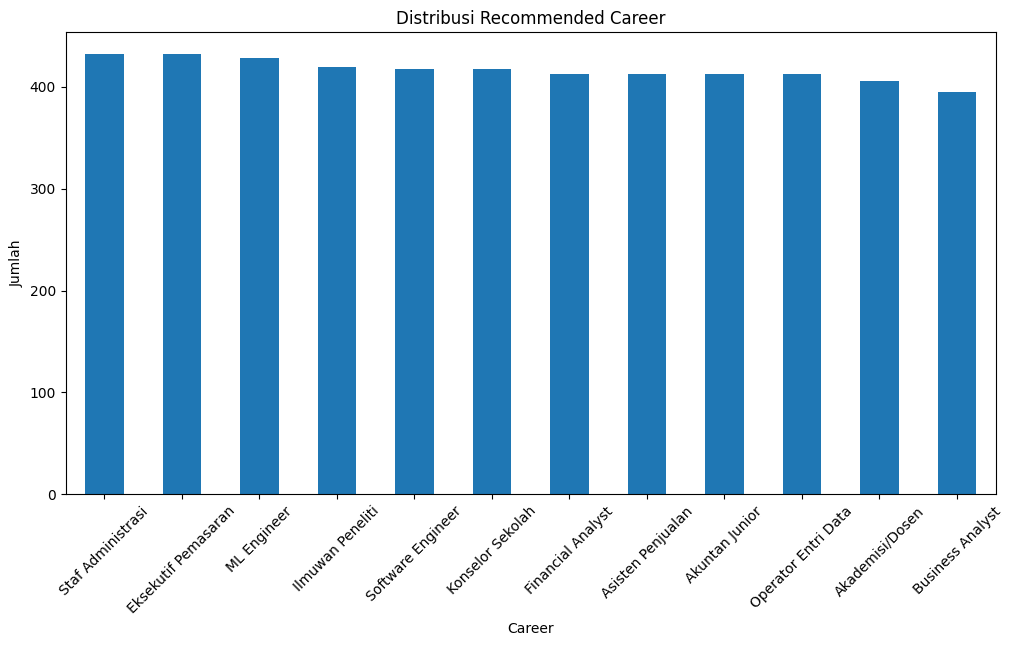

In [32]:
plt.figure(figsize=(12,6))

career_df["Recommended_Career"] \
    .value_counts() \
    .plot(kind="bar")

plt.title("Distribusi Recommended Career")
plt.xlabel("Career")
plt.ylabel("Jumlah")
plt.xticks(rotation=45)

plt.show()

In [33]:
career_df["Specialization"].value_counts().head(10)

Specialization
Engineering         668
Finance             659
Psychology          657
Business            634
Computer Science    608
Arts                604
Commerce            601
Science             567
Name: count, dtype: int64

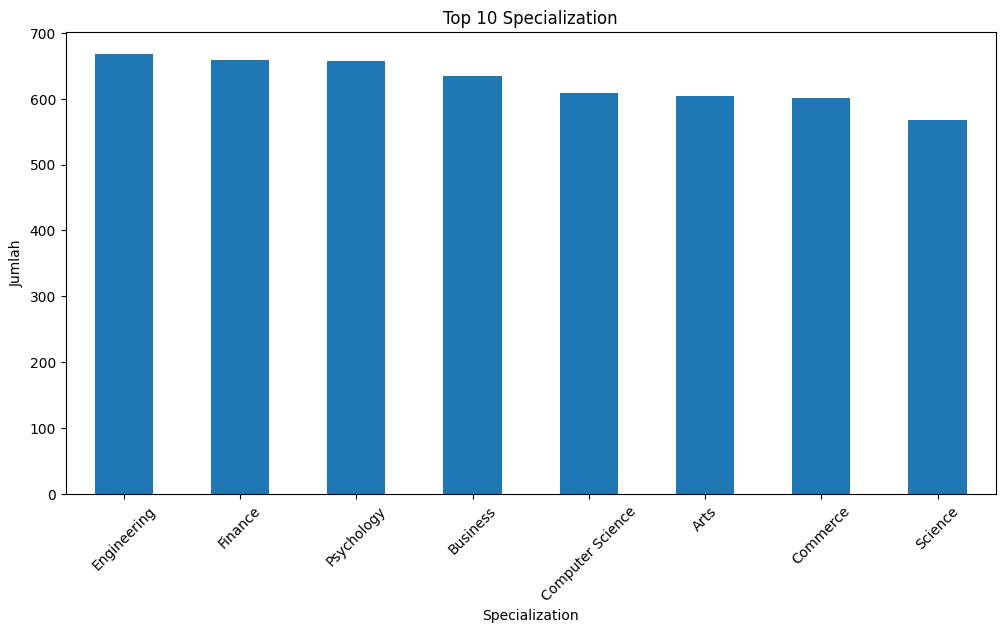

In [34]:
plt.figure(figsize=(12,6))

career_df["Specialization"] \
    .value_counts() \
    .head(10) \
    .plot(kind="bar")

plt.title("Top 10 Specialization")
plt.xlabel("Specialization")
plt.ylabel("Jumlah")
plt.xticks(rotation=45)

plt.show()

In [35]:
all_skills = " ".join(
    career_df["Skills_ID_Categorized"].astype(str)
)

In [36]:
import re

skill_list = re.split(r'[,;/\s]+', all_skills)

skill_series = pd.Series(skill_list)

top_skills = skill_series.value_counts().head(20)

top_skills

&             2883
Keuangan      1876
Akuntansi     1876
Python        1031
Analisis      1007
Data          1007
IT            1007
MS            1005
Office        1005
SQL            992
Pemasaran      992
Konseling      986
Komunikasi     970
Machine        950
Learning       950
Name: count, dtype: int64

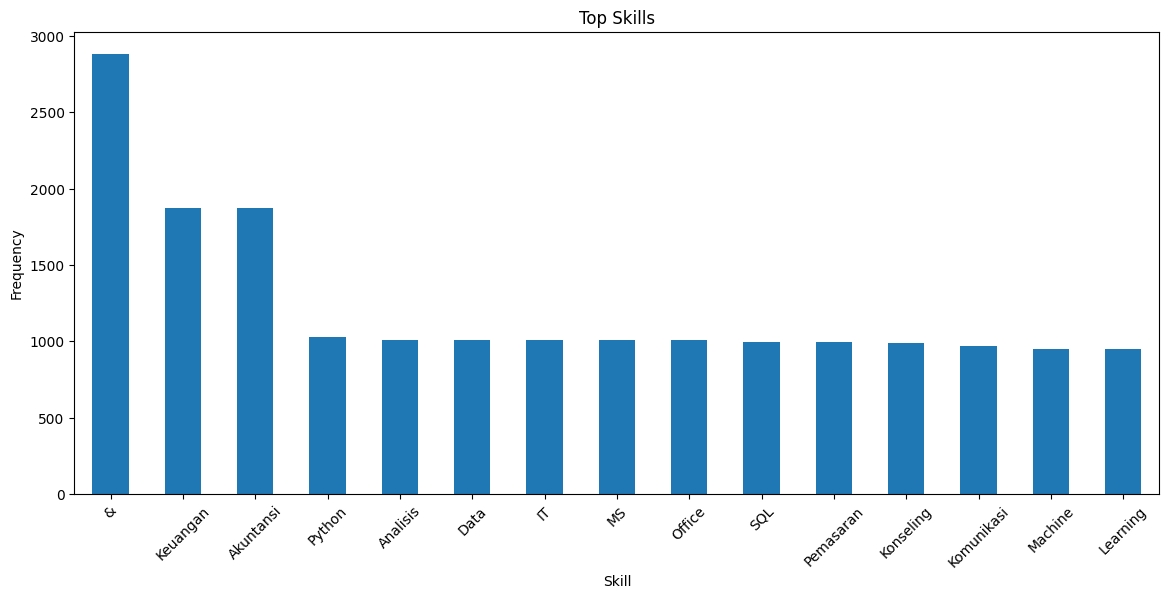

In [37]:
plt.figure(figsize=(14,6))

top_skills.plot(kind="bar")

plt.title("Top Skills")
plt.xlabel("Skill")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

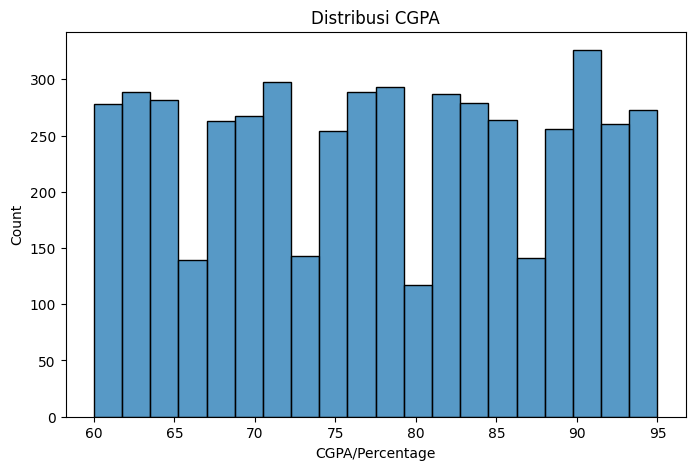

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    career_df["CGPA/Percentage"],
    bins=20
)

plt.title("Distribusi CGPA")
plt.show()

## Insight EDA

Dataset AI Career Navigator memiliki distribusi target karir yang cukup beragam dengan total 12 kategori pekerjaan. Mayoritas data berasal dari bidang teknologi dan komputer, sehingga cocok digunakan untuk pengembangan model rekomendasi karir berbasis machine learning.

Tidak ditemukan missing value yang signifikan, serta hanya terdapat sedikit data duplikat yang telah dibersihkan pada tahap preprocessing awal.